In [8]:
import sys
print(sys.prefix)

c:\Users\valeg\Desktop\ETL 2026\WORKSHOP_02\venv


# Workshop 2: Reporte del pipeline ETL Spotify + Grammys

Este notebook es el reporte del pipeline que armamos en Apache Airflow. El pipeline lee Spotify (CSV) y Grammys (base de datos), valida, transforma, une las dos fuentes y guarda el resultado en `final_analytics.db`.

Aquí los gráficos se calculan con consultas SQL sobre esa base de datos, no sobre el CSV. El código del pipeline está en `dags/` y la documentación completa en el `README.md`.

In [9]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = "data/final_analytics.db"


def consultar(sql):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df


consultar("SELECT COUNT(*) AS filas, SUM(tiene_grammy) AS filas_con_grammy FROM spotify_grammys")

,filas,filas_con_grammy
0,123424,6991


## 1. Popularidad promedio: artistas con Grammy y sin Grammy

,tiene_grammy,popularidad_promedio,filas,grupo
0,0,33.423892,116433,Sin Grammy
1,1,33.680017,6991,Con Grammy


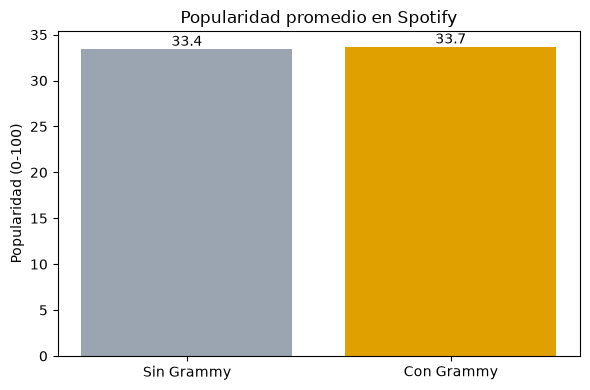

In [10]:
df = consultar(
    """
    SELECT tiene_grammy,
           AVG(popularity) AS popularidad_promedio,
           COUNT(*) AS filas
    FROM spotify_grammys
    GROUP BY tiene_grammy
    """
)
df["grupo"] = df["tiene_grammy"].map({0: "Sin Grammy", 1: "Con Grammy"})
display(df)

plt.figure(figsize=(6, 4))
barras = plt.bar(df["grupo"], df["popularidad_promedio"], color=["#9aa5b1", "#e0a100"])
plt.bar_label(barras, fmt="%.1f")
plt.title("Popularidad promedio en Spotify")
plt.ylabel("Popularidad (0-100)")
plt.tight_layout()
plt.show()

Las dos barras casi empatan: 33,4 de popularidad promedio para los artistas sin Grammy y 33,7 para los que sí tienen. La diferencia es de apenas 0,3 puntos sobre 100, así que ser un artista premiado no se nota en cuánto se escucha hoy en Spotify. El grupo con Grammy es pequeño (cerca del 6% de las filas), por eso la comparación se interpreta con cuidado.

## 2. Perfil sonoro promedio

,tiene_grammy,danceability,energy,valence,acousticness,liveness,speechiness
0,0,0.567,0.630,0.460,0.334,0.216,0.091
1,1,0.564,0.579,0.506,0.361,0.196,0.072


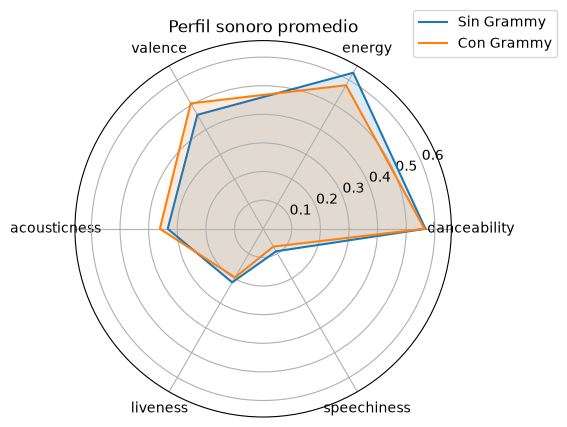

In [11]:
variables = ["danceability", "energy", "valence", "acousticness", "liveness", "speechiness"]
columnas = ", ".join(f"AVG({v}) AS {v}" for v in variables)
df = consultar(
    f"SELECT tiene_grammy, {columnas} FROM spotify_grammys GROUP BY tiene_grammy"
)
display(df.round(3))

angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
for _, fila in df.iterrows():
    valores = [fila[v] for v in variables]
    valores += valores[:1]
    nombre = "Con Grammy" if fila["tiene_grammy"] == 1 else "Sin Grammy"
    ax.plot(angulos, valores, label=nombre)
    ax.fill(angulos, valores, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables)
ax.set_title("Perfil sonoro promedio")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Este radar compara el "perfil sonoro" promedio de las canciones de artistas con Grammy y sin Grammy. Cada eje es una característica de audio que Spotify mide entre 0 y 1, y mientras más lejos del centro está la figura, más alto es ese valor: `danceability` (qué tan bailable es), `energy` (intensidad), `valence` (qué tan alegre o positiva suena), `acousticness` (qué tan acústica es), `liveness` (presencia de público o sonido en vivo) y `speechiness` (presencia de palabras habladas).

Las dos figuras casi se superponen, lo que indica que las canciones de los dos grupos suenan muy parecido en promedio. Las diferencias más notorias son de apenas 0,05 puntos: los artistas sin Grammy tienen más `energy` (0,63 frente a 0,58) y los artistas con Grammy tienen más `valence` (0,51 frente a 0,46). Con Grammy también hay un poco más de `acousticness` (0,36 frente a 0,33), y sin Grammy un poco más de `speechiness` (0,09 frente a 0,07) y `liveness` (0,22 frente a 0,20). En `danceability` no hay diferencia (0,57 en ambos).

Conclusión: con estos datos, ganar un Grammy no se asocia con un sonido distinto. Además, el promedio mezcla todas las canciones de cada artista (no solo las premiadas) y el grupo con Grammy es mucho más pequeño, así que conviene tomar estas diferencias con cuidado.

## 3. Top 10 artistas por premios

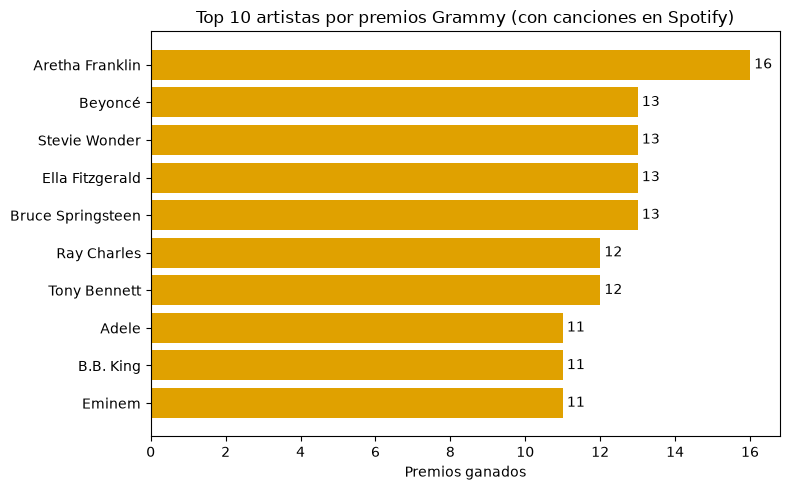

In [12]:
df = consultar(
    """
    SELECT artist_key,
           MAX(premios) AS premios
    FROM spotify_grammys
    WHERE tiene_grammy = 1
    GROUP BY artist_key
    ORDER BY premios DESC
    LIMIT 10
    """
)
df["artista"] = df["artist_key"].str.title()
df = df.sort_values("premios")

plt.figure(figsize=(8, 5))
barras = plt.barh(df["artista"], df["premios"], color="#e0a100")
plt.bar_label(barras, padding=3)
plt.title("Top 10 artistas por premios Grammy (con canciones en Spotify)")
plt.xlabel("Premios ganados")
plt.tight_layout()
plt.show()

Este gráfico muestra los 10 artistas con más premios Grammy que también tienen canciones en Spotify. Aretha Franklin lidera con 16 premios, seguida por Beyoncé, Stevie Wonder, Ella Fitzgerald y Bruce Springsteen con 13 cada uno. Después aparecen Ray Charles y Tony Bennett con 12, y Adele, B.B. King y Eminem con 11.

En el top se mezclan artistas de épocas y géneros muy distintos (soul, jazz, rock, pop y rap). Los números salen del dataset de Grammys, que llega hasta 2019 y solo trae ganadores, y únicamente cuentan artistas que se pudieron cruzar con Spotify por nombre, así que no son el total histórico oficial.

## 4. Relación entre premios y popularidad

Correlación premios vs popularidad: -0.01


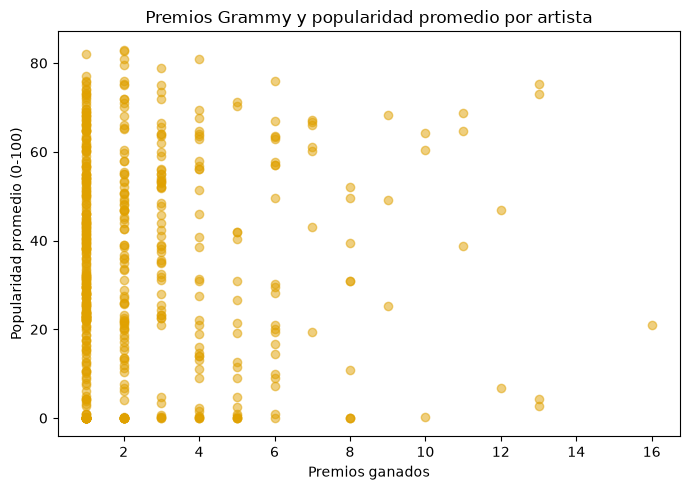

In [13]:
df = consultar(
    """
    SELECT artist_key,
           MAX(premios) AS premios,
           AVG(popularity) AS popularidad_promedio
    FROM spotify_grammys
    WHERE tiene_grammy = 1
    GROUP BY artist_key
    """
)
correlacion = df["premios"].corr(df["popularidad_promedio"])
print(f"Correlación premios vs popularidad: {correlacion:.2f}")

plt.figure(figsize=(7, 5))
plt.scatter(df["premios"], df["popularidad_promedio"], alpha=0.5, color="#e0a100")
plt.title("Premios Grammy y popularidad promedio por artista")
plt.xlabel("Premios ganados")
plt.ylabel("Popularidad promedio (0-100)")
plt.tight_layout()
plt.show()

Cada punto es un artista con Grammy: en el eje X está cuántos premios ganó y en el eje Y la popularidad promedio de sus canciones en Spotify. La correlación es de -0,01, es decir, prácticamente cero: tener más premios no se asocia con ser más popular hoy.

Se nota en la nube de puntos. Los artistas con un solo premio van de 0 hasta cerca de 80 de popularidad, y Aretha Franklin, con 16 premios, ronda los 20. Una posible explicación es que muchos premios son de décadas pasadas, mientras que la popularidad de Spotify mide la escucha actual.

## Conclusión

Los cuatro gráficos apuntan a lo mismo: en estos datos, la popularidad actual en Spotify y el sonido de las canciones casi no cambian entre artistas con Grammy y sin Grammy, y tampoco crece con la cantidad de premios.

Hay que leerlo con cuidado: el cruce se hizo por nombre exacto del artista (solo 524 de los 1.656 artistas de Grammys coincidieron), el dataset de Grammys trae únicamente ganadores, y la popularidad es la de todas las canciones del artista, no la de la obra premiada. Los resultados muestran asociación, no que el premio cause la popularidad.